In [11]:
#PART 3: tarot-images.json EDA
import json
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import os
import cv2
os.makedirs("eda_outputs", exist_ok=True)

In [4]:
# STEP 1: Structural check
with open(r"C:\Users\souri\Downloads\Palmistry & Tarot Intelligence\tarot-images.json", "r") as f:
    tarot_data = json.load(f)

cards = tarot_data["cards"]

# Turn the list of card dictionaries into a table for easy analysis
tarot_df = pd.DataFrame(cards)

print("Total number of cards:", len(cards))
print("\nCards per arcana type:")
print(tarot_df["arcana"].value_counts())

print("\nCards per suit:")
print(tarot_df["suit"].value_counts())

=== STEP 14: Structural check ===
Total number of cards: 78

Cards per arcana type:
arcana
Minor Arcana    56
Major Arcana    22
Name: count, dtype: int64

Cards per suit:
suit
Trump        22
Cups         14
Swords       14
Wands        14
Pentacles    14
Name: count, dtype: int64


In [13]:
# STEP 2: Missingness by arcana group (not overall)

extra_fields = [
    "Numerology", "Astrology", "Affirmation", "Archetype",
    "Elemental", "Hebrew Alphabet", "Mythical/Spiritual", "Questions to Ask"
]

presence_table = {}
for field in extra_fields:
    if field in tarot_df.columns:
        # count how many cards HAVE this field, grouped by arcana
        has_field = tarot_df[field].notnull()
        presence_table[field] = tarot_df.groupby("arcana").apply(
            lambda group: group[field].notnull().sum()
        )

presence_df = pd.DataFrame(presence_table).T
print(presence_df)
print("\nNote: this is NOT random missing data. Major Arcana cards use")
print("Archetype/Hebrew Alphabet/Mythical fields, while Minor Arcana cards")
print("use Astrology/Affirmation fields instead. This is by design.")


arcana              Major Arcana  Minor Arcana
Numerology                    22            40
Astrology                      0            40
Affirmation                    0            56
Archetype                     22             0
Elemental                     22            16
Hebrew Alphabet               22             0
Mythical/Spiritual            22             0
Questions to Ask              22            56

Note: this is NOT random missing data. Major Arcana cards use
Archetype/Hebrew Alphabet/Mythical fields, while Minor Arcana cards
use Astrology/Affirmation fields instead. This is by design.


C:\Users\souri\AppData\Local\Temp\ipykernel_25400\2457356304.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  presence_table[field] = tarot_df.groupby("arcana").apply(
C:\Users\souri\AppData\Local\Temp\ipykernel_25400\2457356304.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  presence_table[field] = tarot_df.groupby("arcana").apply(
C:\Users\souri\AppData\Local\Temp\ipykernel_25400\2457356304.py:13: FutureWa

Top 15 most common keywords across all cards:
  fairness: 3
  evaluation: 3
  decision: 3
  confidence: 3
  faith: 2
  intuition: 2
  reflection: 2
  direction: 2
  passion: 2
  choice: 2
  victory: 2
  triumph: 2
  success: 2
  discipline: 2
  boldness: 2


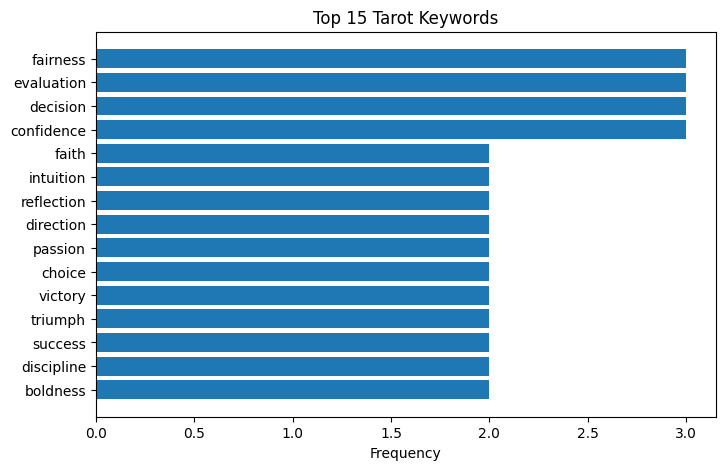


=== PART 3 COMPLETE ===


In [14]:
# STEP 3: Keyword frequency
# ============================================================

keyword_counter = Counter()
for card in cards:
    keyword_counter.update(card.get("keywords", []))

top_keywords = keyword_counter.most_common(15)
print("Top 15 most common keywords across all cards:")
for word, count in top_keywords:
    print(f"  {word}: {count}")

# simple bar chart of top keywords
keywords_df = pd.DataFrame(top_keywords, columns=["keyword", "count"])

plt.figure(figsize=(8, 5))
plt.barh(keywords_df["keyword"], keywords_df["count"])
plt.title("Top 15 Tarot Keywords")
plt.xlabel("Frequency")
plt.gca().invert_yaxis()  # highest count at the top
#plt.tight_layout()
#plt.savefig("eda_outputs/step17_top_keywords.png")
#plt.close()
plt.show()
print("\n=== PART 3 COMPLETE ===")


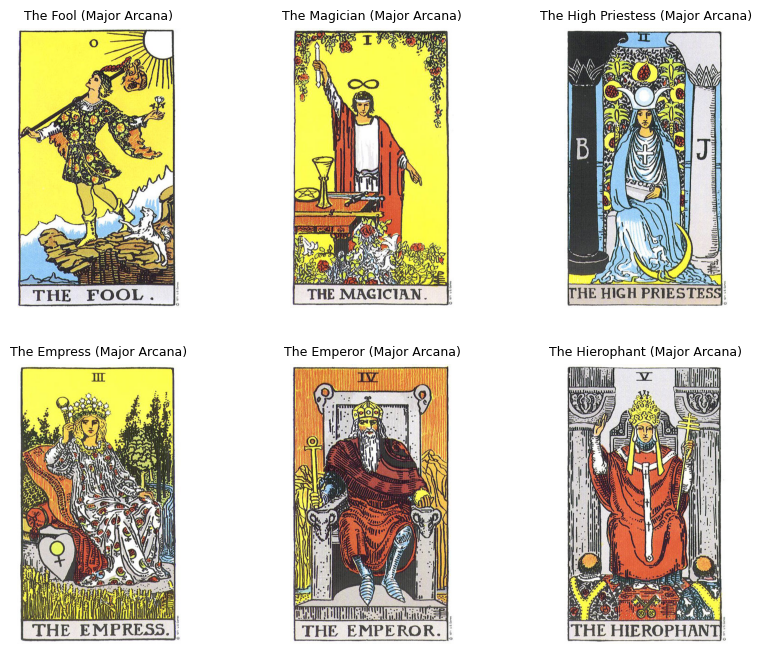

In [15]:
#Display sample tarot card images.

TAROT_IMAGE_DIR = r"C:\Users\souri\Downloads\Palmistry & Tarot Intelligence\cards"

with open(r"C:\Users\souri\Downloads\Palmistry & Tarot Intelligence\tarot-images.json", "r") as f:
    tarot_data = json.load(f)

cards = tarot_data["cards"]
sample_cards = cards[:6]

fig, axes = plt.subplots(2, 3, figsize=(10, 8))

for i, card in enumerate(sample_cards):
    image_path = os.path.join(TAROT_IMAGE_DIR, card["img"])
    img = cv2.imread(image_path)

    row, col = i // 3, i % 3

    if img is None:
        # image file not found - show a blank box with the card name instead
        axes[row, col].text(0.5, 0.5, f"Missing:\n{card['img']}",
                             ha="center", va="center")
        axes[row, col].axis("off")
        continue

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # OpenCV loads as BGR, matplotlib needs RGB
    axes[row, col].imshow(img_rgb)
    axes[row, col].set_title(f"{card['name']} ({card['arcana']})", fontsize=9)
    axes[row, col].axis("off")

#plt.tight_layout()
#plt.savefig("eda_outputs/sample_tarot_cards.png")
plt.show()

#print("Saved to eda_outputs/sample_tarot_cards.png")